# CNN-LSTM — IMU Gym Exercise Recognition (Our Data)

**Data:** `OurData_v5_scaled_20Hz.csv` only

**Task:**
1. Classify each window into one of 10 exercise categories.
2. Classify each window into one of two parent classes (arm curl or bench press).

**Exercises:** (1,1) (1,2) (1,3) (1,4) (5,5) (5,6) (5,7) (5,8) (5,9) (5,10)

**Evaluation:** Leave-One-Subject-Out cross-validation (LOSO)


---
## 0. Setup & Configuration


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data --
DATA_PATH = "data/OurData_v5_scaled_20Hz.csv"

# -- All 10 exercise classes: (parent, child) pairs --
KEEP_PAIRS = [(1,1), (1,2), (1,3), (1,4), (5,5), (5,6), (5,7), (5,8), (5,9), (5,10)]

# Map (parent, child) tuple -> 0-indexed model label
PAIR_TO_LABEL = {pair: idx for idx, pair in enumerate(KEEP_PAIRS)}
LABEL_TO_PAIR = {idx: pair for pair, idx in PAIR_TO_LABEL.items()}
NUM_CLASSES   = len(KEEP_PAIRS)  # 10

# Human-readable class names for plots / reports
CLASS_NAMES = [f"({p},{c})" for p, c in KEEP_PAIRS]

# -- Preprocessing --
SAMPLING_RATE    = 20       # Hz
NUM_IMU_CHANNELS = 6        # accel_xyz + gyro_xyz
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap

# -- Training --
EPOCHS        = 75
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
PATIENCE      = 15

# -- IMU column names (must match your CSV) --
IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]


---
## 1. Mount Google Drive & Load Data


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os

BASE_PATH      = "/content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
FULL_DATA_PATH = os.path.join(BASE_PATH, DATA_PATH)

print(f"Loading: {FULL_DATA_PATH}")
df_full = pd.read_csv(FULL_DATA_PATH)
print(f"Dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Columns: {list(df_full.columns)}")
print(f"Participants: {sorted(df_full['participant'].unique())}")

# Show all (parent, child) pairs present
print(f"\n(parent, child) pair counts:")
pair_counts = df_full.groupby(["parent", "child"]).size().reset_index(name="rows")
print(pair_counts.to_string(index=False))
df_full.head()


Loading: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/OurData_v5_scaled_20Hz.csv
Dataset: 52,828 rows, 11 columns
Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID']
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

(parent, child) pair counts:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542


,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID
0,-0.021239,-0.004765,0.430070,29.726128,-1.790615,17.630320,5,10,15,2,40
1,0.164774,0.034100,0.296485,20.008928,-4.918915,21.764799,5,10,15,2,40
2,1.732960,0.696600,0.234255,-16.202781,-4.881416,-0.725023,5,10,15,2,40
3,3.160571,4.102789,-1.365407,-39.722531,-33.829759,-56.474590,5,10,15,2,40
4,2.117513,4.268014,-0.569065,0.107245,-50.272274,-93.961825,5,10,15,2,40


---
## 2. Filter & Label Data

Keep all 10 exercise pairs and assign each a 0-indexed label:

| (parent, child) | Exercise | Label |
|---|---|---|
| (1,1) | Arm Curl variant 1 | 0 |
| (1,2) | Arm Curl variant 2 | 1 |
| (1,3) | Arm Curl variant 3 | 2 |
| (1,4) | Arm Curl variant 4 | 3 |
| (5,5) | Bench Press variant 1 | 4 |
| (5,6) | Bench Press variant 2 | 5 |
| (5,7) | Bench Press variant 3 | 6 |
| (5,8) | Bench Press variant 4 | 7 |
| (5,9) | Bench Press variant 5 | 8 |
| (5,10) | Bench Press variant 6 | 9 |


In [ ]:
# Keep only rows belonging to the 10 target pairs
pair_mask = pd.Series(False, index=df_full.index)
for p, c in KEEP_PAIRS:
    pair_mask |= (df_full["parent"] == p) & (df_full["child"] == c)

df_filtered = df_full[pair_mask].copy().reset_index(drop=True)

# Assign 0-indexed label from (parent, child) pair
df_filtered["label"] = df_filtered.apply(
    lambda r: PAIR_TO_LABEL[(int(r["parent"]), int(r["child"]))], axis=1
)

print(f"Filtered dataset: {len(df_filtered):,} rows")
print(f"Participants: {sorted(df_filtered['participant'].unique())}")
print(f"Unique IDs:   {df_filtered['ID'].nunique()}")
print(f"\nClass distribution:")
for idx, (p, c) in enumerate(KEEP_PAIRS):
    count = (df_filtered["label"] == idx).sum()
    print(f"  Label {idx:2d}  ({p},{c:2d})  {CLASS_NAMES[idx]:>8s}  →  {count:,} rows")


Filtered dataset: 52,828 rows
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Unique IDs:   98

Class distribution:
  Label  0  (1, 1)     (1,1)  →  5,273 rows
  Label  1  (1, 2)     (1,2)  →  5,595 rows
  Label  2  (1, 3)     (1,3)  →  5,535 rows
  Label  3  (1, 4)     (1,4)  →  5,697 rows
  Label  4  (5, 5)     (5,5)  →  4,356 rows
  Label  5  (5, 6)     (5,6)  →  5,247 rows
  Label  6  (5, 7)     (5,7)  →  4,529 rows
  Label  7  (5, 8)     (5,8)  →  5,629 rows
  Label  8  (5, 9)     (5,9)  →  5,425 rows
  Label  9  (5,10)    (5,10)  →  5,542 rows


In [ ]:
# Quick sanity check: show a sample ID's label sequence
sample_id = df_filtered["ID"].unique()[0]
sample = df_filtered[df_filtered["ID"] == sample_id]
print(f"ID {sample_id}: {len(sample)} rows")
print(f"  Label:       {sample['label'].unique()}")
print(f"  Participant: {sample['participant'].iloc[0]}")
print(f"  Parent:      {sample['parent'].unique()}")
print(f"  Child:       {sample['child'].unique()}")


ID 40: 892 rows
  Label:       [9]
  Participant: 15
  Parent:      [5]
  Child:       [10]


---
## 3. Preprocessing

**Denoising at 20 Hz:** 6th-order zero-phase Butterworth bandpass (1–9 Hz). At 20 Hz, Nyquist = 10 Hz, so 9 Hz is the safe upper bound. This removes DC drift and keeps the core human motion band.

**Unit conversion:** Acceleration converted from G's to m/s² (×9.81) before denoising.

**Segmentation:** 2-second sliding windows with 50% overlap, per recording ID. Window label = majority vote of raw labels within that window.


In [ ]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data at 20 Hz.

    Steps:
      1. Denoise   — 6th-order zero-phase Butterworth bandpass (1–9 Hz)
      2. Normalize  — Per-channel min–max scaling to [0, 1]
      3. Segment    — Sliding window per ID with majority-vote labels
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=1.0, highcut=9.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)  # 40 samples
        self.step_size = int(self.window_size * (1.0 - overlap)) # 20 samples
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {0.5 * self.fs} Hz")
        print(f"  Bandpass:       {self.lowcut}–{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        """
        6th-order zero-phase Butterworth bandpass (1–9 Hz), per channel.
        At 20 Hz sampling, Nyquist = 10 Hz, so 9 Hz is the safe upper bound.
        """
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            print("  Warning: filter band invalid, skipping denoise")
            return data.copy()
        b, a = butter(self.filter_order, [lo, hi], btype="band")
        out = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]  # too short to filter
        return out

    def fit_normalize(self, data):
        """Fit per-channel min/max from training data, return normalized."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data):
        """Apply previously fitted min–max (for validation data)."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data):
        denom = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    def segment_single(self, data, labels):
        """Sliding window on a single continuous sequence."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant"):
        """
        Segment per ID to avoid windows spanning different recordings.

        Returns:
            X:            (N, window_size, channels)
            y:            (N,) integer labels
            participants: (N,) participant ID per window (for LOSO)
        """
        all_X, all_y, all_participants = [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]

            if len(imu) < self.window_size:
                continue  # skip IDs shorter than one window

            windows, window_labels = self.segment_single(imu, labels)
            all_X.extend(windows)
            all_y.extend(window_labels)
            all_participants.extend([participant] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_participants))

In [ ]:
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=1.0,
    highcut=9.0,
)

# Step 0: Convert acceleration from G's to m/s²
print("\nConverting acceleration from G's to m/s²...")
accel_cols = ["x_accel", "y_accel", "z_accel"]
df_filtered[accel_cols] = df_filtered[accel_cols] * 9.81

# Step 1: Denoise
print("Denoising...")
imu_denoised = pp.denoise(df_filtered[IMU_COLS].values)
df_processed = df_filtered.copy()
df_processed[IMU_COLS] = imu_denoised

# Step 2: Normalize (fit on all data — no train/test split here,
# LOSO handles generalisation per-fold)
print("Normalizing...")
df_processed[IMU_COLS] = pp.fit_normalize(df_processed[IMU_COLS].values)
print(f"  Value range: [{df_processed[IMU_COLS].min().min():.4f}, "
      f"{df_processed[IMU_COLS].max().max():.4f}]")

# Step 3: Segment per ID
print("\nSegmenting per ID...")
X, y, participants = pp.segment_by_id(df_processed, IMU_COLS)

print(f"\nResult:")
print(f"  X: {X.shape}  (windows × timesteps × channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes: {np.unique(y)})")
print(f"  Participants: {np.unique(participants)}")
print(f"\nWindows per class:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  Label {idx:2d}  {name:>8s}: {(y == idx).sum()}")


Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       1.0–9.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Converting acceleration from G's to m/s²...
Denoising...
Normalizing...
  Value range: [0.0000, 1.0000]

Segmenting per ID...

Result:
  X: (2493, 40, 6)  (windows × timesteps × channels)
  y: (2493,)  (10 classes: [0 1 2 3 4 5 6 7 8 9])
  Participants: [15 16 17 18 19]

Windows per class:
  Label  0     (1,1): 251
  Label  1     (1,2): 264
  Label  2     (1,3): 261
  Label  3     (1,4): 270
  Label  4     (5,5): 204
  Label  5     (5,6): 247
  Label  6     (5,7): 210
  Label  7     (5,8): 266
  Label  8     (5,9): 257
  Label  9    (5,10): 263


---
## 4. Model — CNN-LSTM


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)

        # CNN
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (batch, channels, seq_len//4)
        x = F.relu(self.bn3(self.conv3(x)))

        # Prepare for LSTM
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq_len_reduced, hidden_dim)
        out = lstm_out[:, -1, :]    # last hidden state

        # Classifier
        out = self.fc(out)
        return out

In [ ]:
# Quick architecture check
test_model = CNN_LSTM(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
test_output = test_model(test_input)

n_params = sum(p.numel() for p in test_model.parameters())
print(f"Input shape:  {tuple(test_input.shape)}")
print(f"Output shape: {tuple(test_output.shape)}")
print(f"Parameters:   {n_params:,}")

del test_model, test_input, test_output

Input shape:  (2, 40, 6)
Output shape: (2, 10)
Parameters:   143,306


---
## 5. LOSO Cross-Validation

**Leave-One-Subject-Out (LOSO):** For each participant, train on all other participants and validate on the held-out one. This gives an unbiased estimate of how well the model generalises to unseen individuals.

We run LOSO twice:
1. **Hyperparameter search** (Section 6) — random search over learning rate, batch size, epochs, patience. Each configuration runs a full LOSO sweep; the best mean F1 wins.
2. **Final LOSO run** (Section 7) — rerun with the best configuration to produce the reported results, confusion matrix, and per-participant breakdown.


In [ ]:
def train_one_fold(model, X_tr, y_tr, X_va, y_va, device,
                   epochs=100, batch_size=64, lr=1e-3, patience=15,
                   verbose=True):
    """
    Train a single LOSO fold with early stopping.

    Returns:
        model:   Best model (weights restored)
        history: Dict of training curves
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = loss_fn(val_logits, y_va_t).item()
            val_acc = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"    Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

In [ ]:
def run_loso(X, y, participants, num_classes, device,
             epochs=100, batch_size=64, lr=1e-3, patience=15):
    """
    Leave-One-Subject-Out cross-validation.

    Trains on all participants except one, validates on the held-out participant,
    then rotates through every participant.
    """
    logo = LeaveOneGroupOut()
    unique_participants = np.unique(participants)
    n_folds = len(unique_participants)

    print(f"LOSO: {n_folds} folds (one per participant)")
    print(f"Participants: {sorted(unique_participants)}")

    results = {
        "participant": [], "acc": [], "prec": [], "rec": [],
        "f1": [], "loss": [], "histories": [],
        "n_train": [], "n_val": [],
        "all_y_true": [], "all_y_pred": [],  # for aggregated confusion matrix
    }

    for fold, (tr_idx, va_idx) in enumerate(logo.split(X, y, participants)):
        held_out = participants[va_idx[0]]
        print(f"\n{'═'*55}")
        print(f"  Fold {fold+1}/{n_folds} — Hold out participant {held_out}")
        print(f"  Train: {len(tr_idx)} windows  |  Val: {len(va_idx)} windows")
        print(f"{'═'*55}")

        # Build fresh model
        model = CNN_LSTM(
            in_channels=X.shape[2],
            num_classes=num_classes,
        ).to(device)

        if fold == 0:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Parameters: {n_params:,}")

        # Train
        model, history = train_one_fold(
            model, X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
            device=device, epochs=epochs, batch_size=batch_size,
            lr=lr, patience=patience,
        )

        # Evaluate
        model.eval()
        with torch.no_grad():
            X_va_t = torch.FloatTensor(X[va_idx]).to(device)
            y_pred = model(X_va_t).argmax(1).cpu().numpy()
        y_true = y[va_idx]

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

        results["participant"].append(held_out)
        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        results["loss"].append(min(history["val_loss"]))
        results["histories"].append(history)
        results["n_train"].append(len(tr_idx))
        results["n_val"].append(len(va_idx))
        results["all_y_true"].extend(y_true)
        results["all_y_pred"].extend(y_pred)

        print(f"\n  Participant {held_out} =>  "
              f"Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%")

    return results

---
## 6. Hyperparameter Search via LOSO


In [ ]:
# # ============================================================
# # Random Hyperparameter Search over full LOSO
# # ============================================================
# import random

# # Define search space
# param_grid = {
#     "lr":         [1e-3, 5e-4, 1e-4],
#     "batch_size":  [32, 64],
#     "epochs":      [50, 75, 100],
#     "patience":    [10, 15, 20],
# }

# # Sample N random configurations (set to however many you can afford)
# N_SAMPLES = 10
# random.seed(42)

# all_combos = [
#     dict(zip(param_grid.keys(), vals))
#     for vals in __import__("itertools").product(*param_grid.values())
# ]
# sampled_configs = random.sample(all_combos, min(N_SAMPLES, len(all_combos)))

# print(f"Search space: {len(all_combos)} total combinations")
# print(f"Sampling {len(sampled_configs)} random configurations\n")

# sweep_results = []

# for i, config in enumerate(sampled_configs):
#     print(f"\n{'='*60}")
#     print(f"  Config {i+1}/{len(sampled_configs)}: {config}")
#     print(f"{'='*60}")

#     loso_out = run_loso(
#         X, y, participants,
#         num_classes=NUM_CLASSES,
#         device=DEVICE,
#         epochs=config["epochs"],
#         batch_size=config["batch_size"],
#         lr=config["lr"],
#         patience=config["patience"],
#     )

#     mean_f1  = np.mean(loso_out["f1"])
#     std_f1   = np.std(loso_out["f1"])
#     mean_acc = np.mean(loso_out["acc"])

#     sweep_results.append({
#         **config,
#         "mean_f1": mean_f1,
#         "std_f1": std_f1,
#         "mean_acc": mean_acc,
#         "loso_output": loso_out,  # keep full results for the winner
#     })

#     print(f"  → Mean F1: {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)  "
#           f"Mean Acc: {mean_acc*100:.2f}%")

# # ---- Pick the best config ----
# sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k != "loso_output"}
#                           for r in sweep_results])
# sweep_df = sweep_df.sort_values("mean_f1", ascending=False).reset_index(drop=True)

# print(f"\n\n{'='*60}")
# print("  SWEEP RESULTS (sorted by Mean F1)")
# print(f"{'='*60}")
# display(sweep_df.round(4))

# # Store best config and its LOSO output for downstream cells
# best_idx = sweep_df.index[0]
# best_config = sampled_configs[sweep_results.index(
#     [r for r in sweep_results
#      if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]
# )]
# results = [r for r in sweep_results
#            if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]["loso_output"]

# best_lr         = best_config["lr"]
# best_batch_size = best_config["batch_size"]
# best_epochs     = best_config["epochs"]
# best_patience   = best_config["patience"]

# print(f"\n✓ Best configuration:")
# print(f"  lr={best_lr}, batch_size={best_batch_size}, "
#       f"epochs={best_epochs}, patience={best_patience}")
# print(f"  Mean F1: {np.mean(results['f1'])*100:.2f}% "
#       f"(±{np.std(results['f1'])*100:.2f}%)")

In [ ]:
# ============================================================
# Train with Best Known Hyperparameters (found via prior sweep)
# ============================================================

best_lr         = 0.0001
best_batch_size = 32
best_epochs     = 100
best_patience   = 15

print(f"Using best configuration from prior hyperparameter sweep:")
print(f"  lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")

results = run_loso(
    X, y, participants,
    num_classes=NUM_CLASSES,
    device=DEVICE,
    epochs=best_epochs,
    batch_size=best_batch_size,
    lr=best_lr,
    patience=best_patience,
)

mean_f1  = np.mean(results["f1"])
std_f1   = np.std(results["f1"])
mean_acc = np.mean(results["acc"])

print(f"\n✓ LOSO Results:")
print(f"  Mean F1:  {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)")
print(f"  Mean Acc: {mean_acc*100:.2f}%")

Using best configuration from prior hyperparameter sweep:
  lr=0.0001, batch_size=32, epochs=100, patience=15
LOSO: 5 folds (one per participant)
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

═══════════════════════════════════════════════════════
  Fold 1/5 — Hold out participant 15
  Train: 1863 windows  |  Val: 630 windows
═══════════════════════════════════════════════════════
  Parameters: 143,306
    Epoch  10  train_loss=0.8040  val_loss=1.6631  val_acc=0.3397  lr=1.0e-04
    Epoch  20  train_loss=0.2917  val_loss=1.6465  val_acc=0.3905  lr=5.0e-05
    Early stopping at epoch 28

  Participant 15 =>  Acc: 39.05%  F1: 36.70%

═══════════════════════════════════════════════════════
  Fold 2/5 — Hold out participant 16
  Train: 2067 windows  |  Val: 426 windows
═══════════════════════════════════════════════════════
    Epoch  10  train_loss=0.7028  val_loss=1.7571  val_acc=0.3685  lr=1.0e-04
    Epoch  20  train_loss=0.2879  val_loss=1.7972 

---
## 7. LOSO Results Summary


In [ ]:
# Per-participant results table
results_df = pd.DataFrame({
    "Participant":  results["participant"],
    "Train Windows": results["n_train"],
    "Val Windows":   results["n_val"],
    "Accuracy (%)":  [a * 100 for a in results["acc"]],
    "Precision (%)":  [p * 100 for p in results["prec"]],
    "Recall (%)":    [r * 100 for r in results["rec"]],
    "F1-score (%)":  [f * 100 for f in results["f1"]],
    "Best Val Loss": results["loss"],
})

print("Per-Participant Results (LOSO)")
print("=" * 70)
display(results_df.round(2))

print(f"\nOverall Averages:")
print(f"  Accuracy:  {np.mean(results['acc'])*100:.2f}% "
      f"(+/- {np.std(results['acc'])*100:.2f}%)")
print(f"  Precision: {np.mean(results['prec'])*100:.2f}% "
      f"(+/- {np.std(results['prec'])*100:.2f}%)")
print(f"  Recall:    {np.mean(results['rec'])*100:.2f}% "
      f"(+/- {np.std(results['rec'])*100:.2f}%)")
print(f"  F1-score:  {np.mean(results['f1'])*100:.2f}% "
      f"(+/- {np.std(results['f1'])*100:.2f}%)")

Per-Participant Results (LOSO)


,Participant,Train Windows,Val Windows,Accuracy (%),Precision (%),Recall (%),F1-score (%),Best Val Loss
0,15,1863,630,39.05,37.74,40.65,36.70,1.59
1,16,2067,426,34.04,29.82,30.55,28.08,1.72
2,17,2041,452,40.04,36.86,36.49,34.82,1.62
3,18,2070,423,47.28,44.19,46.38,44.37,1.39
4,19,1931,562,40.93,40.30,38.83,37.80,1.50



Overall Averages:
  Accuracy:  40.27% (+/- 4.24%)
  Precision: 37.78% (+/- 4.73%)
  Recall:    38.58% (+/- 5.18%)
  F1-score:  36.36% (+/- 5.24%)


---
## 8. Visualize Training Curves


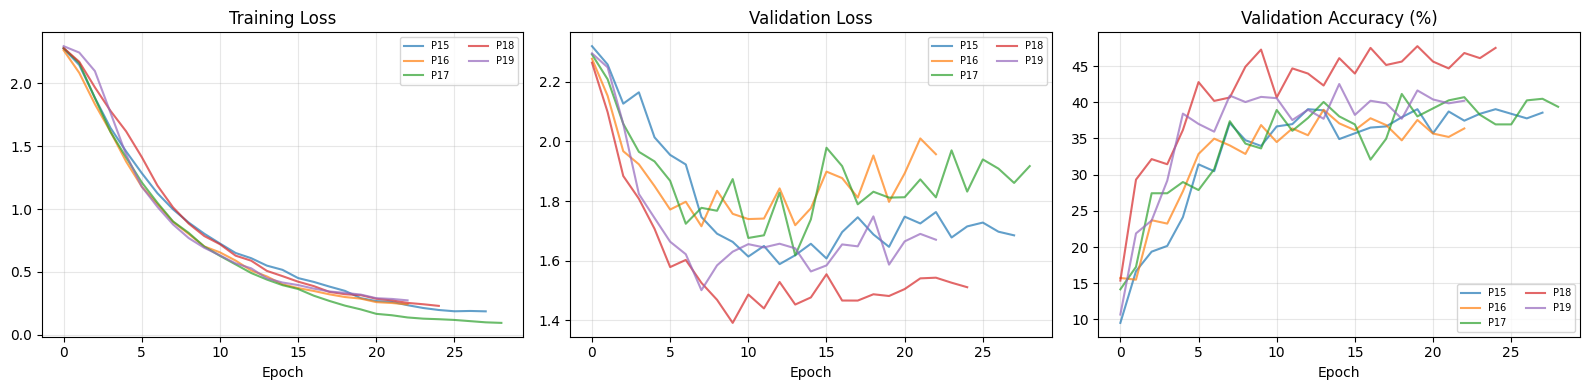

In [ ]:
n_folds = len(results["histories"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, hist in enumerate(results["histories"]):
    p = results["participant"][i]
    axes[0].plot(hist["train_loss"], alpha=0.7, label=f"P{p}")
    axes[1].plot(hist["val_loss"], alpha=0.7, label=f"P{p}")
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.7, label=f"P{p}")

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

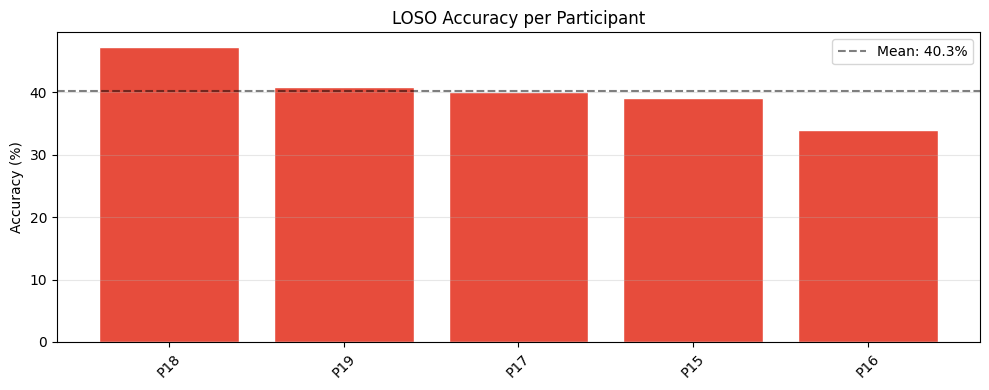

In [ ]:
# Per-participant accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 4))

participants_sorted = sorted(zip(results["participant"], results["acc"]),
                             key=lambda x: x[1], reverse=True)
ps, accs = zip(*participants_sorted)
colors = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.6 else "#e74c3c"
          for a in accs]

ax.bar(range(len(ps)), [a * 100 for a in accs], color=colors, edgecolor="white")
ax.set_xticks(range(len(ps)))
ax.set_xticklabels([f"P{p}" for p in ps], rotation=45)
ax.set_ylabel("Accuracy (%)")
ax.set_title("LOSO Accuracy per Participant")
ax.axhline(y=np.mean(results["acc"]) * 100, color="black",
           linestyle="--", alpha=0.5, label=f"Mean: {np.mean(results['acc'])*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 9. LOSO Confusion Matrix (Aggregated)


In [ ]:
# Use predictions already collected during LOSO (no retraining needed)
all_y_true = np.array(results["all_y_true"])
all_y_pred = np.array(results["all_y_pred"])

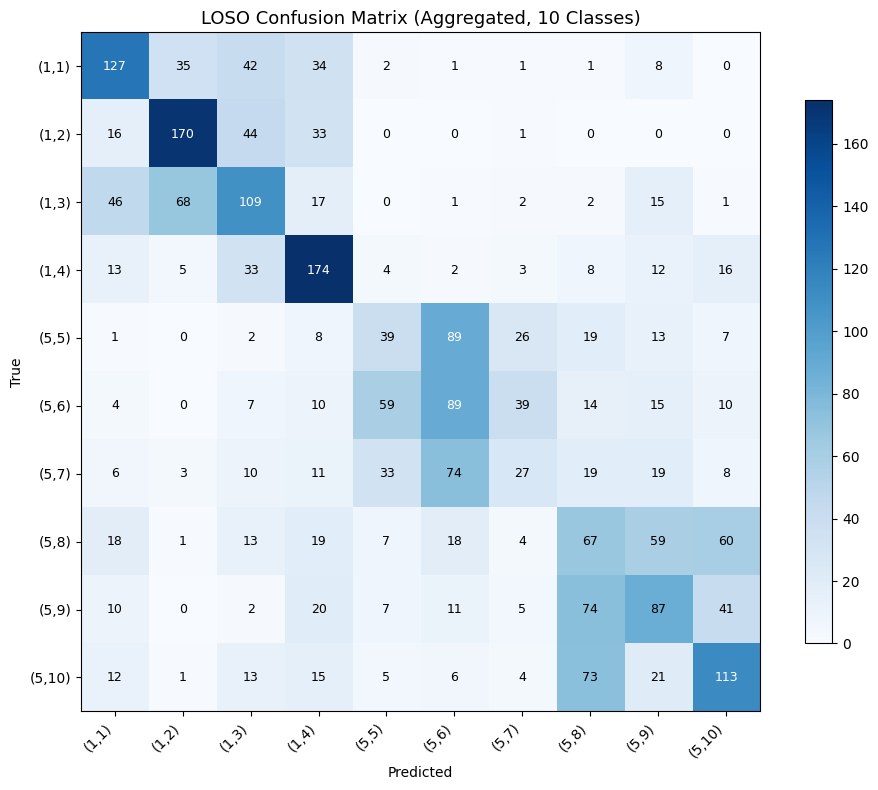


Classification Report:
              precision    recall  f1-score   support

       (1,1)     0.5020    0.5060    0.5040       251
       (1,2)     0.6007    0.6439    0.6216       264
       (1,3)     0.3964    0.4176    0.4067       261
       (1,4)     0.5103    0.6444    0.5696       270
       (5,5)     0.2500    0.1912    0.2167       204
       (5,6)     0.3058    0.3603    0.3309       247
       (5,7)     0.2411    0.1286    0.1677       210
       (5,8)     0.2419    0.2519    0.2468       266
       (5,9)     0.3494    0.3385    0.3439       257
      (5,10)     0.4414    0.4297    0.4355       263

    accuracy                         0.4019      2493
   macro avg     0.3839    0.3912    0.3843      2493
weighted avg     0.3904    0.4019    0.3932      2493



In [ ]:
# Plot 10-class confusion matrix
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=9)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("LOSO Confusion Matrix (Aggregated, 10 Classes)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred,
                            target_names=CLASS_NAMES, digits=4))


Per-Exercise Accuracy (aggregated across all LOSO folds)
     (1,1)   50.60%  (251 windows)
     (1,2)   64.39%  (264 windows)
     (1,3)   41.76%  (261 windows)
     (1,4)   64.44%  (270 windows)
     (5,5)   19.12%  (204 windows)
     (5,6)   36.03%  (247 windows)
     (5,7)   12.86%  (210 windows)
     (5,8)   25.19%  (266 windows)
     (5,9)   33.85%  (257 windows)
    (5,10)   42.97%  (263 windows)

  Overall: 40.19%


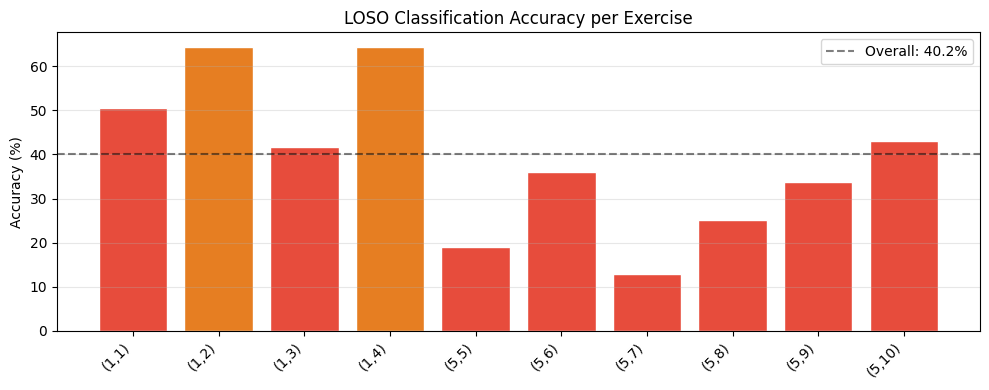

In [ ]:
# Per-exercise accuracy from aggregated LOSO predictions
per_class_acc = []
for label_idx, name in enumerate(CLASS_NAMES):
    mask = all_y_true == label_idx
    if mask.sum() == 0:
        per_class_acc.append((name, 0.0, 0))
    else:
        acc = (all_y_pred[mask] == label_idx).mean()
        per_class_acc.append((name, acc, mask.sum()))

print("Per-Exercise Accuracy (aggregated across all LOSO folds)")
print("=" * 50)
for name, acc, n in per_class_acc:
    print(f"  {name:>8s}  {acc*100:6.2f}%  ({n} windows)")
print(f"\n  Overall: {accuracy_score(all_y_true, all_y_pred)*100:.2f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
names, accs, _ = zip(*per_class_acc)
colors = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.6 else "#e74c3c" for a in accs]
ax.bar(range(NUM_CLASSES), [a * 100 for a in accs], color=colors, edgecolor="white")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("LOSO Classification Accuracy per Exercise")
ax.axhline(y=accuracy_score(all_y_true, all_y_pred) * 100, color="black",
           linestyle="--", alpha=0.5,
           label=f"Overall: {accuracy_score(all_y_true, all_y_pred)*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 10. Save / Load Model


In [ ]:
# Save the model from the final LOSO run
# (last fold's weights — retrain on all data if you want a deployment model)
# save_path = os.path.join(BASE_PATH, "cnn_lstm_10class_imu.pt")
# torch.save(model.state_dict(), save_path)
# print(f"Model saved to: {save_path}")

save_path = os.path.join(BASE_PATH, "cnn_lstm_10class_imu.pt")
# Build a fresh model and save its architecture/state for later inference
final_model = CNN_LSTM(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
torch.save(final_model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/cnn_lstm_10class_imu.pt


In [ ]:
# Load for inference
loaded_model = CNN_LSTM(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
).to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path, map_location=DEVICE))
loaded_model.eval()

# Predict on a single window
sample = torch.FloatTensor(X[:1]).to(DEVICE)
with torch.no_grad():
    logits = loaded_model(sample)
    probs  = torch.softmax(logits, dim=1)
    pred   = logits.argmax(1).item()

print(f"Predicted class: {pred}  →  {CLASS_NAMES[pred]}  (pair {LABEL_TO_PAIR[pred]})")
print(f"\nClass probabilities:")
for i, (name, prob) in enumerate(zip(CLASS_NAMES, probs[0].cpu().numpy())):
    bar = '█' * int(prob * 40)
    print(f"  {name:>8s}  {prob:.4f}  {bar}")


Predicted class: 2  →  (1,3)  (pair (1, 3))

Class probabilities:
     (1,1)  0.0977  ███
     (1,2)  0.1046  ████
     (1,3)  0.1103  ████
     (1,4)  0.0973  ███
     (5,5)  0.0945  ███
     (5,6)  0.0974  ███
     (5,7)  0.0995  ███
     (5,8)  0.0900  ███
     (5,9)  0.1039  ████
    (5,10)  0.1047  ████


---
## 11. Visual Inspection: Ground Truth vs Predictions (LOSO)


In [ ]:
# Rebuild per-fold predictions (re-trains each fold for the visualisation)
logo = LeaveOneGroupOut()
fold_data = []

for fold, (tr_idx, va_idx) in enumerate(logo.split(X, y, participants)):
    held_out = participants[va_idx[0]]

    model = CNN_LSTM(in_channels=X.shape[2], num_classes=NUM_CLASSES).to(DEVICE)
    model, _ = train_one_fold(
        model, X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
        device=DEVICE, epochs=EPOCHS, batch_size=BATCH_SIZE,
        lr=LEARNING_RATE, patience=PATIENCE, verbose=False,
    )
    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(X[va_idx]).to(DEVICE)).argmax(1).cpu().numpy()

    fold_data.append({
        "participant": held_out,
        "y_true": y[va_idx],
        "y_pred": preds,
    })
    acc = accuracy_score(y[va_idx], preds)
    print(f"  Fold {fold+1} done (participant {held_out})  acc={acc*100:.1f}%")


  Fold 1 done (participant 15)  acc=36.0%
  Fold 2 done (participant 16)  acc=31.2%
  Fold 3 done (participant 17)  acc=38.9%
  Fold 4 done (participant 18)  acc=49.4%
  Fold 5 done (participant 19)  acc=44.8%


In [ ]:
# n_folds = len(fold_data)
# fig, axes = plt.subplots(n_folds, 1, figsize=(16, 2.8 * n_folds), sharex=False)
# if n_folds == 1:
#     axes = [axes]

# for ax, fd in zip(axes, fold_data):
#     windows = np.arange(len(fd["y_true"]))
#     ax.scatter(windows, fd["y_true"], c="#2ecc71", s=8, alpha=0.7,
#                label="Ground Truth", zorder=2)
#     ax.scatter(windows, fd["y_pred"] + 0.1, c="#e74c3c", s=8, alpha=0.7,
#                label="Predicted", zorder=2)

#     mismatches = fd["y_true"] != fd["y_pred"]
#     if mismatches.any():
#         ax.scatter(windows[mismatches], fd["y_pred"][mismatches] + 0.1,
#                    c="#e74c3c", s=30, edgecolors="black", linewidths=0.5,
#                    alpha=0.9, zorder=3, label="Misclassified")

#     acc = accuracy_score(fd["y_true"], fd["y_pred"])
#     n_wrong = mismatches.sum()
#     ax.set_title(f"Participant {fd['participant']} — Acc: {acc*100:.1f}%  "
#                  f"({n_wrong} errors / {len(fd['y_true'])} windows)", fontsize=10)
#     ax.set_yticks(range(NUM_CLASSES))
#     ax.set_yticklabels(CLASS_NAMES, fontsize=8)
#     ax.legend(loc="upper right", fontsize=8)
#     ax.grid(True, alpha=0.2)

# axes[-1].set_xlabel("Window Index")
# fig.suptitle("LOSO: Ground Truth vs Predictions (10 Classes)", fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()


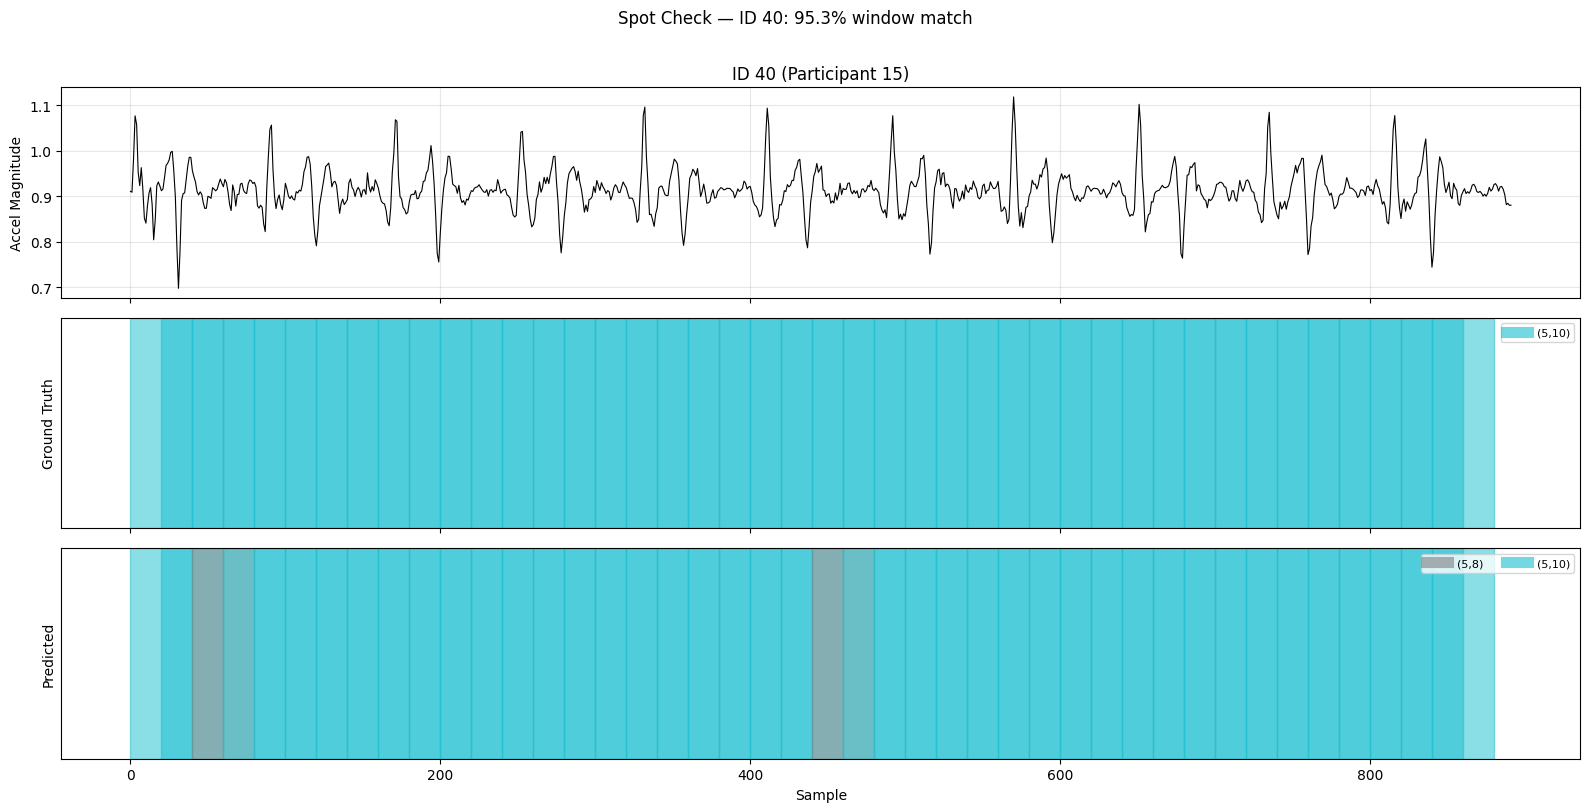

In [ ]:
# Spot-check a single recording ID from the first fold
spot_participant = fold_data[0]["participant"]
spot_ids = df_processed[df_processed["participant"] == spot_participant]["ID"].unique()
spot_id  = spot_ids[0]

spot_df     = df_processed[df_processed["ID"] == spot_id].reset_index(drop=True)
spot_imu    = spot_df[IMU_COLS].values
spot_labels = spot_df["label"].values

spot_windows, spot_wlabels = pp.segment_single(spot_imu, spot_labels)
spot_X = np.array(spot_windows, dtype=np.float32)
spot_y = np.array(spot_wlabels, dtype=np.int64)

model.eval()
with torch.no_grad():
    spot_preds = model(torch.FloatTensor(spot_X).to(DEVICE)).argmax(1).cpu().numpy()

# Use a colour palette for 10 classes
import matplotlib.cm as cm_lib
palette = cm_lib.get_cmap("tab10", NUM_CLASSES)
colors_map = {i: palette(i) for i in range(NUM_CLASSES)}

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

accel_mag = np.sqrt((spot_imu[:, :3] ** 2).sum(axis=1))
axes[0].plot(accel_mag, color="black", linewidth=0.8)
axes[0].set_ylabel("Accel Magnitude")
axes[0].set_title(f"ID {spot_id} (Participant {spot_participant})")
axes[0].grid(True, alpha=0.3)

for panel, preds_arr, title in [
    (axes[1], spot_y,     "Ground Truth"),
    (axes[2], spot_preds, "Predicted"),
]:
    for i, lbl in enumerate(preds_arr):
        start = i * pp.step_size
        end   = start + pp.window_size
        panel.axvspan(start, end, alpha=0.5, color=colors_map[lbl])
    panel.set_ylabel(title)
    panel.set_yticks([])
    # Legend (show each class that actually appears)
    present = sorted(set(preds_arr))
    for lbl in present:
        panel.plot([], [], color=colors_map[lbl], linewidth=8,
                   alpha=0.6, label=CLASS_NAMES[lbl])
    panel.legend(loc="upper right", fontsize=8, ncol=2)

axes[2].set_xlabel("Sample")
match_pct = (spot_y == spot_preds).mean() * 100
fig.suptitle(f"Spot Check — ID {spot_id}: {match_pct:.1f}% window match",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
